# Random Forest Classification Analysis for All Datasets

This notebook applies Random Forest classification with nested cross-validation to all three datasets:
1. **Telco Customer Churn** - Predicting customer churn
2. **Online Shoppers Intention** - Predicting purchase intention
3. **Bank Marketing** - Predicting term deposit subscription

## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

print('Libraries imported successfully!')

Libraries imported successfully!


## Shared helper: encode features

The cleaned CSVs still contain string and boolean categorical columns that must be
one-hot encoded. Random Forests do not require scaling and handle negative values
natively, so no clipping or standardisation is applied.

In [2]:
def encode_features(X):
    """One-hot encode remaining categorical/bool columns."""
    cat_cols = X.select_dtypes(include=['object', 'str', 'bool']).columns.tolist()
    if cat_cols:
        X = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=float)
    return X.astype(float)

## Shared helper: run nested CV + final evaluation

Nested CV structure:
- **Outer loop** (`StratifiedKFold`, 5 folds): estimates generalisation performance without bias.
- **Inner loop** (`GridSearchCV` + `StratifiedKFold`, 5 folds): selects best `n_estimators`, `max_depth`, and `max_features` using `roc_auc`.

After nested CV, the pipeline is refit on the full training set (70%) with the best
hyperparameters. A feature importance plot is produced from the final fitted model.

In [3]:
def run_rf_pipeline(X, y, feature_names, dataset_name, class_labels):

    print(f"\n{'='*60}")
    print(f'  {dataset_name}')
    print(f"{'='*60}")
    print(f'Class distribution:\n{pd.Series(y).value_counts()}')

    # ------------------------------------------------------------------
    # 1. Train / test split  (NO preprocessing happens here)
    # ------------------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=42
    )
    print(f'\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

    # ------------------------------------------------------------------
    # 2. Pipeline: RandomForest only (no scaling needed for trees)
    # ------------------------------------------------------------------
    pipe = Pipeline([
        ('rf', RandomForestClassifier(
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
        )),
    ])

    param_grid = {
        'rf__n_estimators': [100, 200],
        'rf__max_depth':    [None, 10, 20],
        'rf__max_features': ['sqrt', 'log2'],
    }

    # ------------------------------------------------------------------
    # 3. Nested cross-validation
    # ------------------------------------------------------------------
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    inner_search = GridSearchCV(
        pipe,
        param_grid,
        cv=inner_cv,
        scoring='roc_auc',
        n_jobs=-1,
    )

    nested_scores = cross_val_score(
        inner_search,
        X_train, y_train,
        cv=outer_cv,
        scoring='roc_auc',
        n_jobs=-1,
    )

    print(f'\nNested CV ROC-AUC scores: {np.round(nested_scores, 4)}')
    print(f'Mean: {nested_scores.mean():.4f}  (+/- {nested_scores.std():.4f})')

    # ------------------------------------------------------------------
    # 4. Final model: refit on full training set with best hyperparameters
    # ------------------------------------------------------------------
    inner_search.fit(X_train, y_train)
    best_params = inner_search.best_params_
    print(f'\nBest hyperparameters selected by inner CV:')
    for k, v in best_params.items():
        print(f'  {k}: {v}')

    # ------------------------------------------------------------------
    # 5. Evaluation on held-out test set
    # ------------------------------------------------------------------
    y_pred  = inner_search.predict(X_test)
    y_proba = inner_search.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, y_proba)
    test_f1 = f1_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)
    print(f'\nTest set ROC-AUC: {test_auc:.4f}')
    print(f'\nClassification report (test set):')
    print(classification_report(y_test, y_pred, target_names=class_labels))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels).plot(
        cmap='BuPu', colorbar=False
    )
    plt.title(f'{dataset_name} — Confusion Matrix (test set)')
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------
    # 6. Feature importance plot (top 15)
    # ------------------------------------------------------------------
    final_rf = inner_search.best_estimator_.named_steps['rf']
    importances = final_rf.feature_importances_
    indices = np.argsort(importances)[::-1][:15]
    top_names = np.array(feature_names)[indices]
    top_vals  = importances[indices]

    plt.figure(figsize=(8, 5))
    plt.barh(range(15), top_vals[::-1], color='#7F77DD')
    plt.yticks(range(15), top_names[::-1], fontsize=10)
    plt.xlabel('Mean decrease in impurity')
    plt.title(f'{dataset_name} — Top 15 Feature Importances')
    plt.tight_layout()
    plt.show()

    n_features = X_train.shape[1]

    train_acc = accuracy_score(y_train, inner_search.predict(X_train))
    valid_acc = accuracy_score(y_test, y_pred)

    return {
        'dataset':              dataset_name,
        'features':             n_features,
        'best_params':          best_params,
        'train_accuracy':       train_acc,
        'valid_accuracy':       valid_acc,
        'mean_cv_score':        nested_scores.mean(),
        'cv_score_std':         nested_scores.std(),
        'test_auc':             test_auc,
        'test_f1':              test_f1,
        'test_precision':       test_precision,
        'test_recall':          test_recall,
    }

---
## 1. Telco Customer Churn Dataset


In [4]:
df_telco = pd.read_csv('../data/processed/telco_clean.csv')
print(f'Shape: {df_telco.shape}')
print(df_telco.head())

Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

In [5]:
X_telco = df_telco.drop(columns=['customerID', 'Churn'])
y_telco = df_telco['Churn'].values

X_telco = encode_features(X_telco)

print(f'Features: {X_telco.shape}  |  Target distribution: {dict(pd.Series(y_telco).value_counts())}')

Features: (7043, 30)  |  Target distribution: {0: np.int64(5174), 1: np.int64(1869)}



  Telco Customer Churn
Class distribution:
0    5174
1    1869
Name: count, dtype: int64

Train size: 4930  |  Test size: 2113



Nested CV ROC-AUC scores: [0.8358 0.8562 0.8339 0.8408 0.8567]
Mean: 0.8447  (+/- 0.0099)



Best hyperparameters selected by inner CV:
  rf__max_depth: 10
  rf__max_features: sqrt
  rf__n_estimators: 100

Test set ROC-AUC: 0.8375

Classification report (test set):
              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.83      1552
       Churn       0.55      0.73      0.63       561

    accuracy                           0.77      2113
   macro avg       0.72      0.76      0.73      2113
weighted avg       0.80      0.77      0.78      2113



<Figure size 600x500 with 0 Axes>

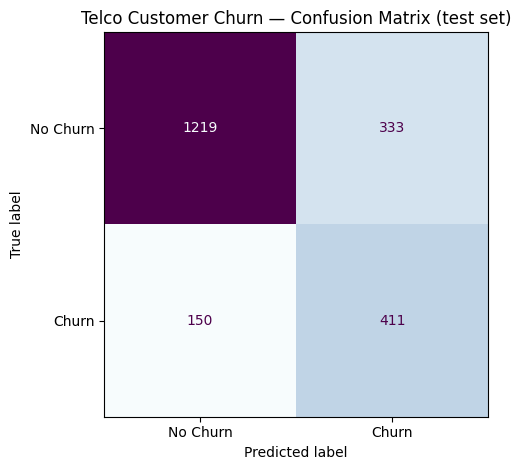

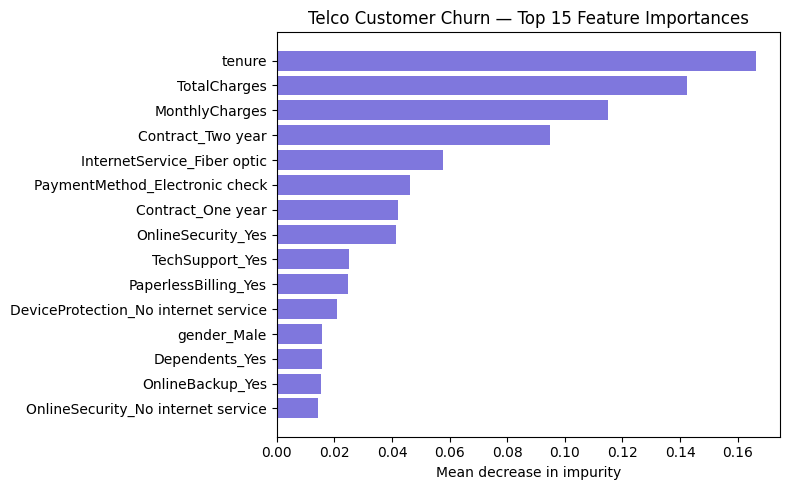

In [6]:
results_telco = run_rf_pipeline(
    X_telco.values, y_telco,
    feature_names=X_telco.columns.tolist(),
    dataset_name='Telco Customer Churn',
    class_labels=['No Churn', 'Churn'],
)

---
## 2. Online Shoppers Intention Dataset

In [7]:
df_ecom = pd.read_csv('../data/processed/ecom_clean.csv')
print(f'Shape: {df_ecom.shape}')
print(df_ecom.head())

Shape: (12205, 18)
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0  

In [8]:
X_ecom = df_ecom.drop(columns=['Revenue'])
y_ecom = df_ecom['Revenue'].values

X_ecom = encode_features(X_ecom)

print(f'Features: {X_ecom.shape}  |  Target distribution: {dict(pd.Series(y_ecom).value_counts())}')

Features: (12205, 26)  |  Target distribution: {0: np.int64(10297), 1: np.int64(1908)}



  Online Shoppers Intention
Class distribution:
0    10297
1     1908
Name: count, dtype: int64

Train size: 8543  |  Test size: 3662



Nested CV ROC-AUC scores: [0.934  0.9321 0.9223 0.9194 0.9268]
Mean: 0.9269  (+/- 0.0055)



Best hyperparameters selected by inner CV:
  rf__max_depth: 20
  rf__max_features: log2
  rf__n_estimators: 200

Test set ROC-AUC: 0.9242

Classification report (test set):
              precision    recall  f1-score   support

 No Purchase       0.92      0.96      0.94      3090
    Purchase       0.71      0.56      0.63       572

    accuracy                           0.90      3662
   macro avg       0.82      0.76      0.78      3662
weighted avg       0.89      0.90      0.89      3662



<Figure size 600x500 with 0 Axes>

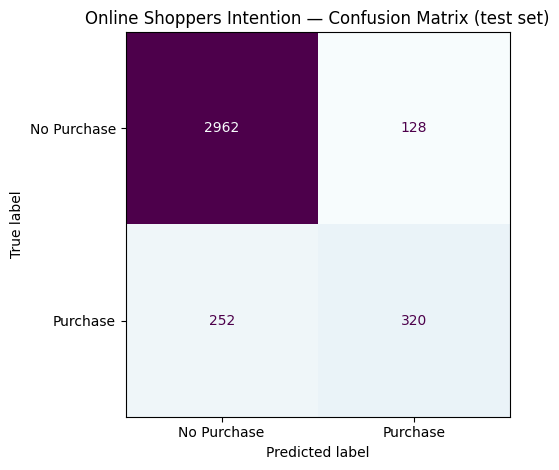

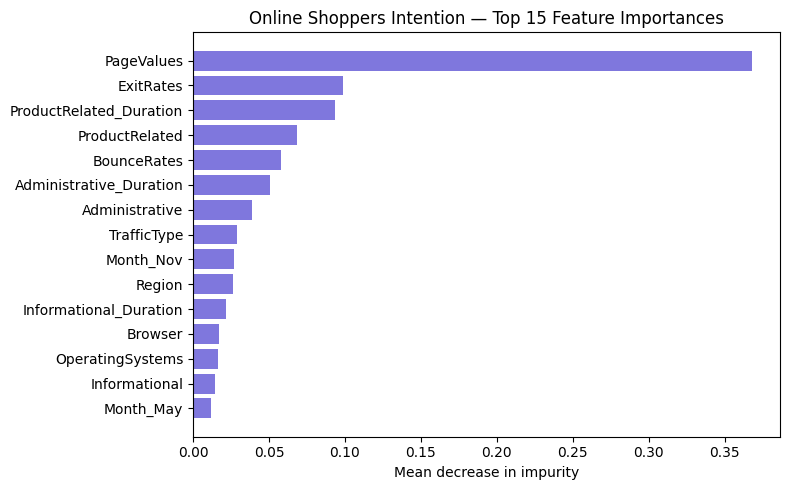

In [9]:
results_ecom = run_rf_pipeline(
    X_ecom.values, y_ecom,
    feature_names=X_ecom.columns.tolist(),
    dataset_name='Online Shoppers Intention',
    class_labels=['No Purchase', 'Purchase'],
)

---
## 3. Bank Marketing Dataset

In [10]:
df_bank = pd.read_csv('../data/processed/bank_clean.csv')
print(f'Shape: {df_bank.shape}')
print(df_bank.head())

Shape: (41176, 21)
   age        job  marital    education default housing loan    contact month  \
0   56  housemaid  married     basic.4y      no      no   no  telephone   may   
1   57   services  married  high.school      no      no   no  telephone   may   
2   37   services  married  high.school      no     yes   no  telephone   may   
3   40     admin.  married     basic.6y      no      no   no  telephone   may   
4   56   services  married  high.school      no      no  yes  telephone   may   

  day_of_week  ...  campaign  pdays  previous  poutcome emp.var.rate  \
0         mon  ...         1    6.0         0   failure          1.1   
1         mon  ...         1    6.0         0   failure          1.1   
2         mon  ...         1    6.0         0   failure          1.1   
3         mon  ...         1    6.0         0   failure          1.1   
4         mon  ...         1    6.0         0   failure          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed  y  

In [11]:
X_bank = df_bank.drop(columns=['y'])
y_bank = df_bank['y'].values

X_bank = encode_features(X_bank)

print(f'Features: {X_bank.shape}  |  Target distribution: {dict(pd.Series(y_bank).value_counts())}')

Features: (41176, 46)  |  Target distribution: {0: np.int64(36537), 1: np.int64(4639)}



  Bank Marketing
Class distribution:
0    36537
1     4639
Name: count, dtype: int64



Train size: 28823  |  Test size: 12353



Nested CV ROC-AUC scores: [0.9456 0.9436 0.9513 0.9417 0.9406]
Mean: 0.9445  (+/- 0.0038)



Best hyperparameters selected by inner CV:
  rf__max_depth: None
  rf__max_features: sqrt
  rf__n_estimators: 200

Test set ROC-AUC: 0.9426

Classification report (test set):
                 precision    recall  f1-score   support

No Subscription       0.93      0.97      0.95     10961
   Subscription       0.65      0.43      0.51      1392

       accuracy                           0.91     12353
      macro avg       0.79      0.70      0.73     12353
   weighted avg       0.90      0.91      0.90     12353



<Figure size 600x500 with 0 Axes>

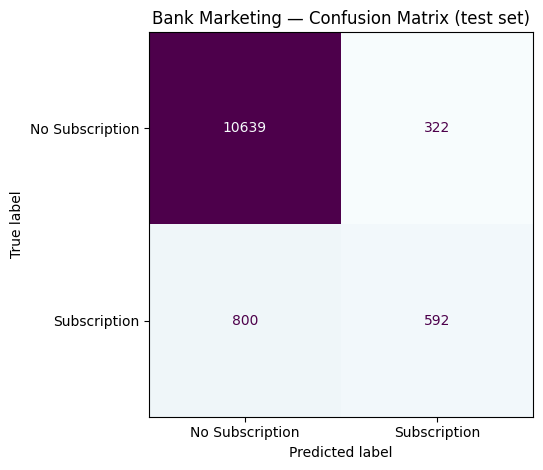

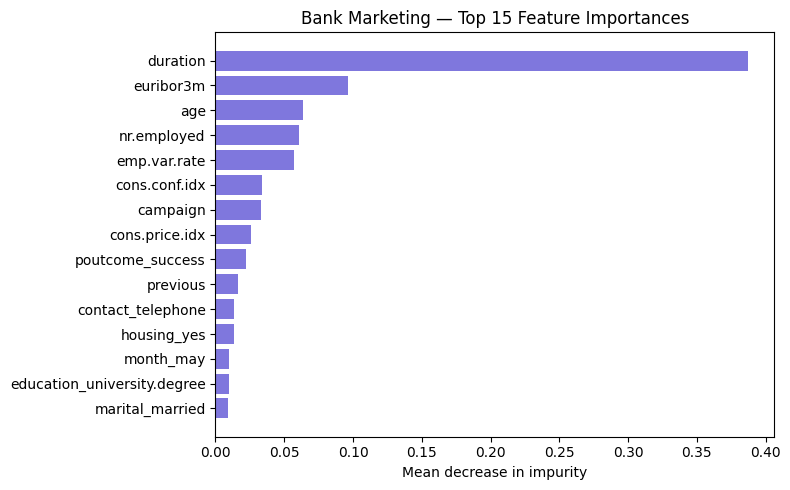

In [12]:
results_bank = run_rf_pipeline(
    X_bank.values, y_bank,
    feature_names=X_bank.columns.tolist(),
    dataset_name='Bank Marketing',
    class_labels=['No Subscription', 'Subscription'],
)

---
## Summary

In [13]:
summary = pd.DataFrame([results_telco, results_ecom, results_bank])

def _fmt_params(p):
    depth = p['rf__max_depth'] if p['rf__max_depth'] is not None else '∞'
    return f"{depth} / {p['rf__max_features']} / {p['rf__n_estimators']}"

summary_out = pd.DataFrame({
    'Dataset':                summary['dataset'],
    'Tiefe / Merkm. / Bäume': summary['best_params'].map(_fmt_params),
    'CV-AUC':                 [f"{m:.4f} ± {s:.4f}" for m, s in zip(summary['mean_cv_score'], summary['cv_score_std'])],
    'Test-AUC':               summary['test_auc'].map('{:.4f}'.format),
    'F1':                     summary['test_f1'].map('{:.4f}'.format),
    'Prec.':                  summary['test_precision'].map('{:.4f}'.format),
    'Recall':                 summary['test_recall'].map('{:.4f}'.format),
})

print('Model Performance Summary (Random Forest - RandomForestClassifier):')
print(summary_out.to_string(index=False))


Model Performance Summary (Random Forest - RandomForestClassifier):
                  Dataset Tiefe / Merkm. / Bäume          CV-AUC Test-AUC     F1  Prec. Recall
     Telco Customer Churn        10 / sqrt / 100 0.8447 ± 0.0099   0.8375 0.6299 0.5524 0.7326
Online Shoppers Intention        20 / log2 / 200 0.9269 ± 0.0055   0.9242 0.6275 0.7143 0.5594
           Bank Marketing         ∞ / sqrt / 200 0.9445 ± 0.0038   0.9426 0.5134 0.6477 0.4253
